In [1]:
import torchvision

print(torchvision.__version__)

0.22.0+cu118


In [2]:
import torch
from torch import optim as optim
from torchvision.models.detection import RetinaNet
from torchvision.models.detection.retinanet import RetinaNetHead
from torchvision.models import mobilenet_v3_large
from torchvision.models.detection.backbone_utils import IntermediateLayerGetter, FeaturePyramidNetwork

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda:0") # Use the first GPU
    print(f"Training on GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA not available. Training on CPU.")

Training on GPU: NVIDIA GeForce RTX 2060 SUPER


In [4]:
from torchvision.models.detection import RetinaNet
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.backbone_utils import _validate_trainable_layers
from torchvision.models import mobilenet_v3_large
from torchvision.ops import FeaturePyramidNetwork

# 1️⃣ Create a backbone
mobilenet_backbone = mobilenet_v3_large(weights="IMAGENET1K_V1").features

# Select layers that produce good feature maps for FPN
backbone_out_channels = [40, 112, 160]  # example MobileNetV3 feature map channels
fpn = FeaturePyramidNetwork(in_channels_list=backbone_out_channels, out_channels=256)

class MobileNetBackbone(torch.nn.Module):
    def __init__(self, body, fpn):
        super().__init__()
        self.body = body
        self.fpn = fpn

    def forward(self, x):
        features = []
        for i, block in enumerate(self.body):
            x = block(x)
            # Pick some layers for FPN
            if i in {3, 6, 12}:  # adjust indices
                features.append(x)
        # Create dict for FPN
        features = {str(idx): f for idx, f in enumerate(features)}
        return self.fpn(features)

    @property
    def out_channels(self):
        return 256

backbone = MobileNetBackbone(mobilenet_backbone, fpn)

# 2️⃣ Define anchor generator matching the number of FPN outputs
# If FPN outputs 3 feature maps, you need 3 tuples here
anchor_generator = AnchorGenerator(
    sizes=((32,), (64,), (128,)),       # one tuple per feature map
    aspect_ratios=((0.5, 1.0, 2.0),) * 3
)

# 3️⃣ Create RetinaNet model
model = RetinaNet(backbone, num_classes=2, anchor_generator=anchor_generator)
model.to(device)


RetinaNet(
  (backbone): MobileNetBackbone(
    (body): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          )
        )
      )
      (2): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivati

In [5]:
import torch
from torchvision.models.detection import RetinaNet
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone

# Create a RetinaNet model with a ResNet-18 backbone
# pretrained=True loads weights from ImageNet for the backbone
backbone = resnet_fpn_backbone('resnet18', pretrained=True)

model = RetinaNet(backbone=backbone, num_classes=2)  # change to your number of classes



e:\PD1ModelTrainings\DLenv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
e:\PD1ModelTrainings\DLenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\PD1ModelTrainings\DLenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
import torch
from torchvision.datasets import CocoDetection
from torchvision import transforms as T
import os

class CocoDetectionRetinaNet(CocoDetection):
    def __init__(self, root, annFile, transform=None):
        super(CocoDetectionRetinaNet, self).__init__(root, annFile)
        self.transform = transform

    def __getitem__(self, idx):
        img, ann = super().__getitem__(idx)

        boxes = []
        labels = []

        for obj in ann:
            if 'iscrowd' in obj and obj['iscrowd']:
                continue

            bbox = obj['bbox']
            x1 = bbox[0]
            y1 = bbox[1]
            x2 = bbox[0] + bbox[2]
            y2 = bbox[1] + bbox[3]

            boxes.append([x1, y1, x2, y2])
            labels.append(obj['category_id'])

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        if self.transform is not None:
            img = self.transform(img)

        return img, target


In [8]:
!pip install pycocotools

In [8]:
from torchvision.datasets import CocoDetection
from torchvision.transforms import ToTensor

train_ds = CocoDetectionRetinaNet(root='cocoshrimpdataset/train',
                         annFile='cocoshrimpdataset/annotations/_annotations_train.coco.json',
                         transform=ToTensor())

test_ds = CocoDetectionRetinaNet(root='cocoshrimpdataset/test',
                        annFile='cocoshrimpdataset/annotations/_annotations_test.coco.json',
                        transform=ToTensor())

val_ds = CocoDetectionRetinaNet(root='cocoshrimpdataset/valid',
                       annFile='cocoshrimpdataset/annotations/_annotations_valid.coco.json',
                       transform=ToTensor())

loading annotations into memory...
Done (t=0.46s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


In [9]:
from torch.utils.data import DataLoader

train_dl = DataLoader(train_ds,
                      batch_size=8,
                      shuffle=True,
                      collate_fn=lambda batch: tuple(zip(*batch)))

test_dl = DataLoader(test_ds,
                     batch_size=8,
                     shuffle=False,
                     collate_fn=lambda batch: tuple(zip(*batch)))

val_dl = DataLoader(val_ds,
                    batch_size=8,
                    shuffle=False,
                    collate_fn=lambda batch: tuple(zip(*batch)))

In [11]:
import torch
from tqdm import tqdm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10
best_loss = float("inf")  # Initialize with infinity
save_dir = "runs/"
os.makedirs(save_dir, exist_ok=True)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, targets in tqdm(train_dl, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True):

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]


        if any(t['boxes'].numel() == 0 for t in targets):
            continue

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())


        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()

    avg_loss = running_loss / len(train_dl)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")


    if avg_loss < best_loss:
        best_loss = avg_loss
        best_model_path = os.path.join(save_dir, "retinanet_best_loss.pth")
        torch.save(model.state_dict(), best_model_path)
        print(f"🔥 New best model saved with loss {best_loss:.4f} at {best_model_path}")
    else:
        print(f"No improvement. Best loss remains {best_loss:.4f}")


Using device: cuda


Epoch 1/10: 100%|██████████| 518/518 [37:58<00:00,  4.40s/it]


Epoch [1/10] - Loss: 0.7160
🔥 New best model saved with loss 0.7160 at runs/retinanet_best_loss.pth


Epoch 2/10: 100%|██████████| 518/518 [37:41<00:00,  4.37s/it]


Epoch [2/10] - Loss: 0.5280
🔥 New best model saved with loss 0.5280 at runs/retinanet_best_loss.pth


...

Epoch [8/10] - Loss: 0.3574
🔥 New best model saved with loss 0.3574 at runs/retinanet_best_loss.pth


Epoch 9/10: 100%|██████████| 518/518 [37:48<00:00,  4.38s/it]


Epoch [9/10] - Loss: 0.3469
🔥 New best model saved with loss 0.3469 at runs/retinanet_best_loss.pth


Epoch 10/10: 100%|██████████| 518/518 [36:51<00:00,  4.27s/it]

Epoch [10/10] - Loss: 0.3278
🔥 New best model saved with loss 0.3278 at runs/retinanet_best_loss.pth


In [15]:
import torch
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load model weights correctly
model.load_state_dict(torch.load("runs/retinanet_best_loss.pth", map_location="cpu"))
model.to(device)
model.eval()

running_box_loss = 0.0

with torch.no_grad():
    # ✅ temporarily enable training mode to get losses
    model.train()
    for images, targets in tqdm(test_dl, desc="Evaluating (Loss)"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        if any(t['boxes'].numel() == 0 for t in targets):
            continue

        # Now returns a dict with losses
        loss_dict = model(images, targets)
        running_box_loss += loss_dict["bbox_regression"].item()

    model.eval()  # switch back to eval mode

avg_box_loss = running_box_loss / len(test_dl)
print(f"Average Box Loss on Test Set: {avg_box_loss:.4f}")


Using device: cuda


Evaluating (Loss): 100%|██████████| 25/25 [00:28<00:00,  1.13s/it]

Average Box Loss on Test Set: 0.2391


In [19]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import torch

metric = MeanAveragePrecision(iou_type="bbox")  # default computes mAP@0.5:0.95
# You can also specify only IoU=0.5 if desired:
# metric = MeanAveragePrecision(iou_thresholds=[0.5])

model.eval()
with torch.no_grad():
    for images, targets in tqdm(test_dl, desc="Evaluating (mAP)"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        preds = model(images)  # outputs: list of dicts [{boxes, scores, labels}, ...]

        # Format predictions and targets for torchmetrics
        preds = [
            {
                "boxes": p["boxes"].detach().cpu(),
                "scores": p["scores"].detach().cpu(),
                "labels": p["labels"].detach().cpu(),
            }
            for p in preds
        ]
        targets = [
            {
                "boxes": t["boxes"].detach().cpu(),
                "labels": t["labels"].detach().cpu(),
            }
            for t in targets
        ]

        metric.update(preds, targets)

# ✅ Compute final results
results = metric.compute()
print(results)
print(f"mAP@50: {results['map_50']:.4f}")


Evaluating (mAP): 100%|██████████| 25/25 [00:23<00:00,  1.08it/s]


{'map': tensor(0.4574), 'map_50': tensor(0.7898), 'map_75': tensor(0.4984), 'map_small': tensor(0.4659), 'map_medium': tensor(0.2873), 'map_large': tensor(0.4861), 'mar_1': tensor(0.0181), 'mar_10': tensor(0.1491), 'mar_100': tensor(0.5532), 'mar_small': tensor(0.5580), 'mar_medium': tensor(0.4019), 'mar_large': tensor(0.5300), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(1, dtype=torch.int32)}
mAP@50: 0.7898


In [17]:
import torch
import time
from tqdm import tqdm

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

total_time = 0.0
num_images = 0

with torch.no_grad():
    for images, targets in tqdm(test_dl, desc="Measuring Inference Time"):
        images = [img.to(device) for img in images]

        # Measure inference time
        torch.cuda.synchronize() if device.type == "cuda" else None
        start_time = time.time()

        preds = model(images)

        torch.cuda.synchronize() if device.type == "cuda" else None
        end_time = time.time()

        # Compute average per image in batch
        batch_time = (end_time - start_time)
        total_time += batch_time
        num_images += len(images)

avg_inference_time = total_time / num_images
print(f"⚡ Average inference time per image: {avg_inference_time:.4f} seconds")
print(f"🧮 ≈ {1/avg_inference_time:.2f} FPS")



Measuring Inference Time: 100%|██████████| 25/25 [00:28<00:00,  1.15s/it]

⚡ Average inference time per image: 0.1383 seconds
🧮 ≈ 7.23 FPS


In [18]:
with torch.no_grad():
    for idx, (images, _) in enumerate(tqdm(test_dl, desc="Per-image Timing")):
        images = [img.to(device) for img in images]

        torch.cuda.synchronize() if device.type == "cuda" else None
        start = time.time()

        preds = model(images)

        torch.cuda.synchronize() if device.type == "cuda" else None
        end = time.time()

        print(f"Image {idx+1}: {(end - start):.4f} seconds")


Per-image Timing:   4%|▍         | 1/25 [00:01<00:29,  1.25s/it]

Image 1: 1.1733 seconds


Per-image Timing:   8%|▊         | 2/25 [00:02<00:23,  1.03s/it]

Image 2: 0.8196 seconds


Per-image Timing:  12%|█▏        | 3/25 [00:02<00:21,  1.05it/s]

...

Image 23: 0.8153 seconds


Per-image Timing:  96%|█████████▌| 24/25 [00:21<00:00,  1.14it/s]

Image 24: 0.8067 seconds


Per-image Timing: 100%|██████████| 25/25 [00:22<00:00,  1.13it/s]

Image 25: 0.4825 seconds


In [21]:
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    for images, targets in test_dl:
        imgs = [img.to(device) for img in images]
        preds = model(imgs)  # list of dicts: boxes, scores, labels
        for p in preds[:3]:
            boxes = p['boxes'].cpu()
            scores = p['scores'].cpu()
            areas = (boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1])
            print("Top scores:", scores[:10])
            print("Box areas:", areas[:10])
        break


Top scores: tensor([0.9431, 0.9088, 0.8177, 0.7800, 0.7263, 0.7156, 0.6941, 0.6939, 0.6765,
        0.6751])
Box areas: tensor([581.3977, 510.3941, 498.3798, 417.6814, 396.7128, 358.0922, 234.9662,
        449.1046, 193.4815, 393.3155])
Top scores: tensor([0.8958, 0.8430, 0.7947, 0.7722, 0.7066, 0.6153, 0.5822, 0.5379, 0.4478,
        0.4407])
Box areas: tensor([1131.8677,  375.4094,  476.8827,  324.1971,  496.9981,  332.9278,
         245.4175,  231.0022,  301.1781,  233.1678])
Top scores: tensor([0.8203, 0.8080, 0.7773, 0.7586, 0.7473, 0.7219, 0.7208, 0.6871, 0.6841,
        0.6693])
Box areas: tensor([400.0052, 408.6700, 431.8080, 288.6432, 405.2994, 439.9673, 319.8192,
        379.9981, 282.6722, 360.0783])


Using device: cuda
✅ Model loaded successfully!
✅ Output image saved at: output_detected.jpg


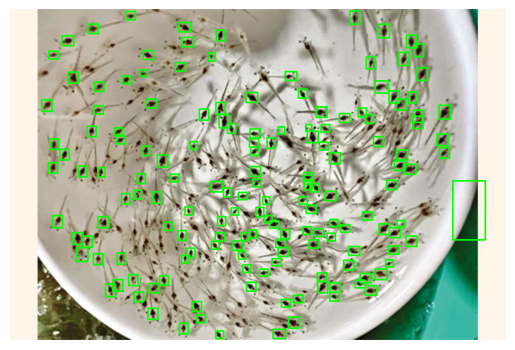

In [28]:
import torch
import torchvision
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.models.detection import RetinaNet
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone

# --- SETTINGS ---
model_path = "runs/retinanet_best_loss.pth"   # your trained weights
image_path = "test.jpg"                 # input image
save_path = "output_detected.jpg"             # output path
num_classes = 2                               # your dataset (e.g., background + shrimp)
class_names = ["background", "shrimp"]        # update based on your labels

# --- DEVICE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- LOAD MODEL (RetinaNet + ResNet18-FPN) ---
backbone = resnet_fpn_backbone('resnet18', pretrained=False)
model = RetinaNet(backbone=backbone, num_classes=num_classes)
model.to(device)

# --- LOAD WEIGHTS ---
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint)
model.eval()
print("✅ Model loaded successfully!")

# --- LOAD IMAGE ---
image = Image.open(image_path).convert("RGB")
transform = transforms.Compose([transforms.ToTensor()])
img_tensor = transform(image).to(device)

# --- INFERENCE ---
with torch.no_grad():
    outputs = model([img_tensor])

# --- PROCESS OUTPUT ---
output = outputs[0]
boxes = output["boxes"].cpu().numpy()
scores = output["scores"].cpu().numpy()
labels = output["labels"].cpu().numpy()

# --- DRAW DETECTIONS ---
image_cv = np.array(image)
image_cv = cv2.cvtColor(image_cv, cv2.COLOR_RGB2BGR)

confidence_threshold = 0.5
for box, score, label in zip(boxes, scores, labels):
    if score < confidence_threshold:
        continue
    x1, y1, x2, y2 = box.astype(int)
    color = (0, 255, 0)
    # Draw bounding box only (no label text)
    cv2.rectangle(image_cv, (x1, y1), (x2, y2), color, 2)


# --- SAVE AND SHOW OUTPUT ---
cv2.imwrite(save_path, image_cv)
print(f"✅ Output image saved at: {save_path}")

image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.show()